<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/SEMANA_6/Tarea4/Tarea_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BILLETES


EDA

In [2]:

# ------------------------------------------------------------
# 1. Importación de librerías
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='deep', font_scale=1.1)

# ------------------------------------------------------------
# 2. Carga del dataset
# ------------------------------------------------------------
url = "https://raw.githubusercontent.com/MiguelAngeloTr/Aprendizaje_Automatico/refs/heads/main/SEMANA_5/TAREA3/data_billetes.csv"
billetes = pd.read_csv(url)

print("Dataset cargado correctamente.")
print(f"Filas: {billetes.shape[0]}  |  Columnas: {billetes.shape[1]}")
billetes.head()




Dataset cargado correctamente.
Filas: 1372  |  Columnas: 5


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:


# ------------------------------------------------------------
# 3. Información general del dataset
# ------------------------------------------------------------
print("\nInformación general del DataFrame:")
billetes.info()

print("\nResumen estadístico de las variables numéricas:")
display(billetes.describe().T)

# ------------------------------------------------------------
# 4. Revisión de valores nulos y duplicados
# ------------------------------------------------------------
print("\nValores nulos por columna:")
print(billetes.isnull().sum())

print("\nRegistros duplicados:")
print(billetes.duplicated().sum())
print(billetes[billetes.duplicated()])



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000



Valores nulos por columna:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Registros duplicados:
24
     variance  skewness  curtosis  entropy  class
47    -0.7869    9.5663   -3.7867  -7.5034      0
139   -0.2062    9.2207   -3.7044  -6.8103      0
190    0.9297   -3.7971    4.6429  -0.2957      0
195   -1.8584    7.8860   -1.6643  -1.8384      0
226    0.5706   -0.0248    1.2421  -0.5621      0
268    0.9297   -3.7971    4.6429  -0.2957      0
284   -1.3000   10.2678   -2.9530  -5.8638      0
300    0.3292   -4.4552    4.5718  -0.9888      0
315    0.3292   -4.4552    4.5718  -0.9888      0
320    0.5195   -3.2633    3.0895  -0.9849      0
345   -1.8584    7.8860   -1.6643  -1.8384      0
351    0.5195   -3.2633    3.0895  -0.9849      0
352    0.3292   -4.4552    4.5718  -0.9888      0
404    0.3798    0.7098    0.7572  -0.4444      0
427   -1.3000   10.2678   -2.9530  -5.8638      0
436    0.3798    0.7098    0.7572  -0.4444      0
476    0.3798


Registros duplicados:
0
(1348, 5)


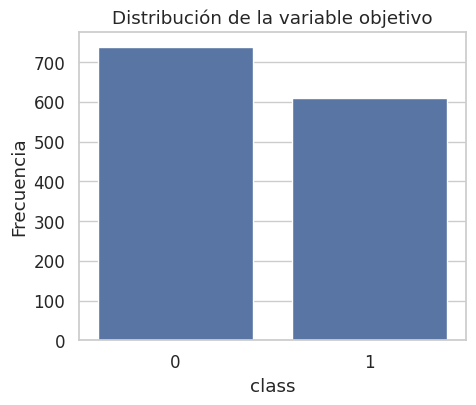

In [4]:
#Eliminar duplicados
billetes = billetes.drop_duplicates()
print("\nRegistros duplicados:")
print(billetes.duplicated().sum())

print(billetes.shape)
# ------------------------------------------------------------
# 5. Distribución de la variable objetivo
# ------------------------------------------------------------
# Se asume que la última columna corresponde a la variable objetivo
target_col = 'target_class' if 'target_class' in billetes.columns else billetes.columns[-1]

plt.figure(figsize=(5,4))
sns.countplot(data=billetes, x=target_col)
plt.title('Distribución de la variable objetivo')
plt.xlabel(target_col)
plt.ylabel('Frecuencia')
plt.show()


Se decide que el desbalanceo es leve y no requiere tecnicas de balanceo

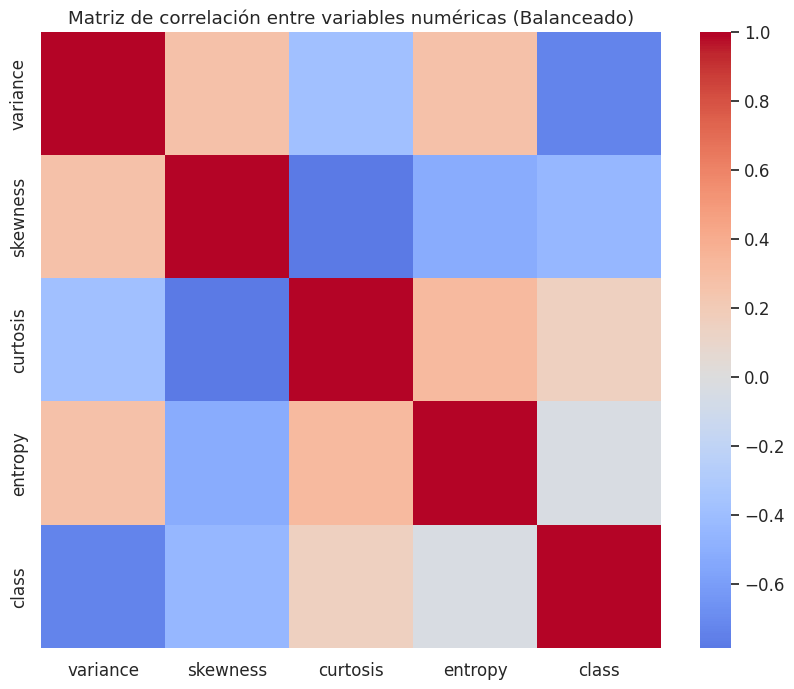

In [5]:

# ------------------------------------------------------------
# 6. Matriz de correlación
# ------------------------------------------------------------
plt.figure(figsize=(10,8))
corr = billetes.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables numéricas (Balanceado)')
plt.show()


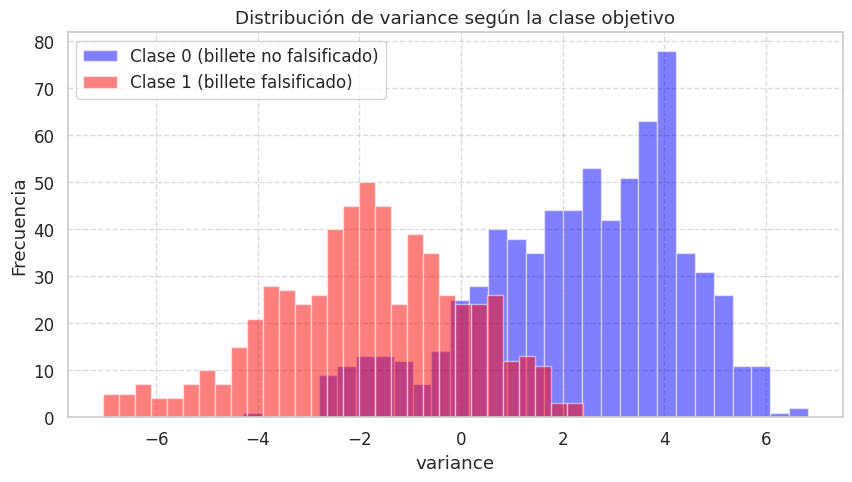

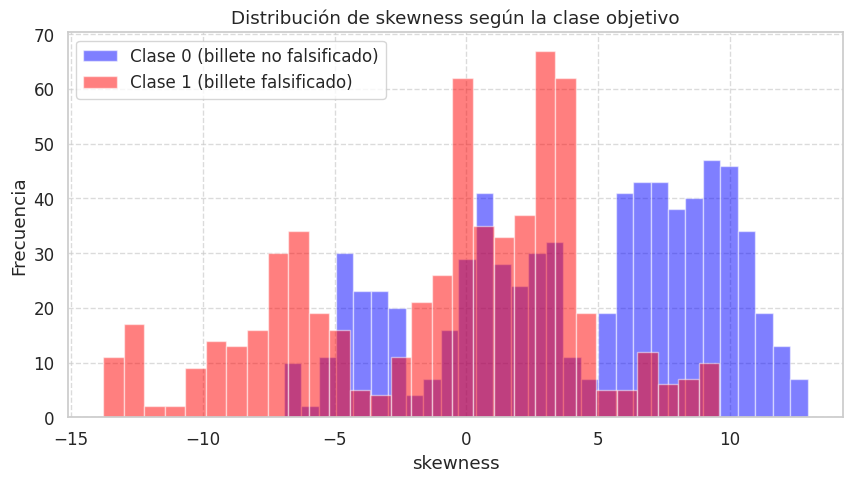

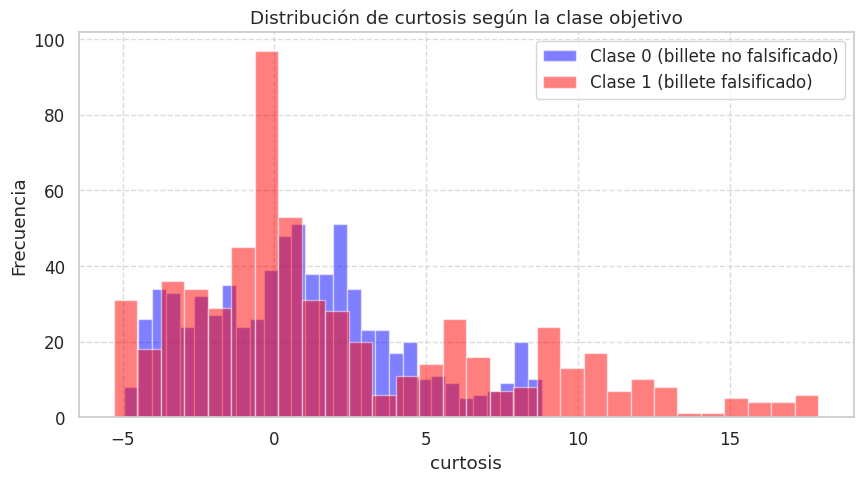

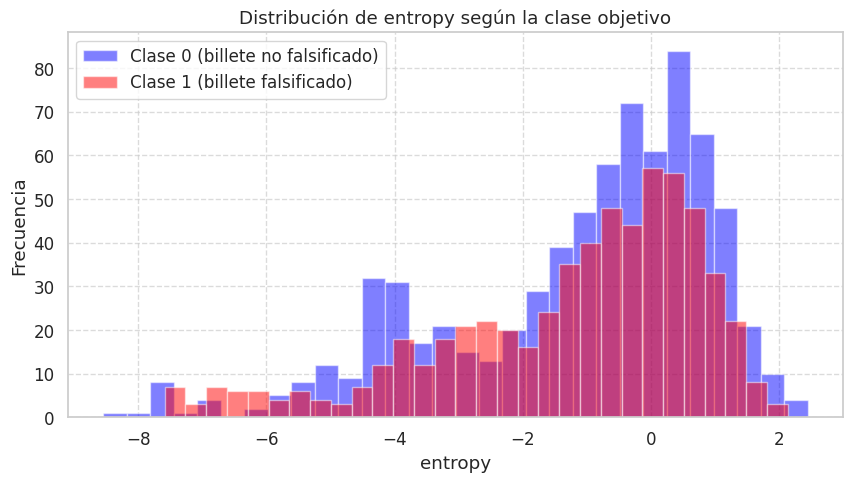

In [6]:
# -----------------------------------------
# COMPARACIÓN DE DISTRIBUCIONES POR CLASE
# -----------------------------------------

import matplotlib.pyplot as plt

# Identificar variable objetivo
target_col = 'target_class' if 'target_class' in billetes.columns else billetes.columns[-1]

# Definir características numéricas (todas menos la target)
features = [col for col in billetes.columns if col != target_col]

# Crear histogramas comparativos por clase
for feature in features:
    plt.figure(figsize=(10, 5))

    billetes[billetes[target_col] == 0][feature].plot(
        kind='hist', alpha=0.5, color='blue', bins=30, label='Clase 0 (billete no falsificado)')

    billetes[billetes[target_col] == 1][feature].plot(
        kind='hist', alpha=0.5, color='red', bins=30, label='Clase 1 (billete falsificado)')

    plt.title(f'Distribución de {feature} según la clase objetivo')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

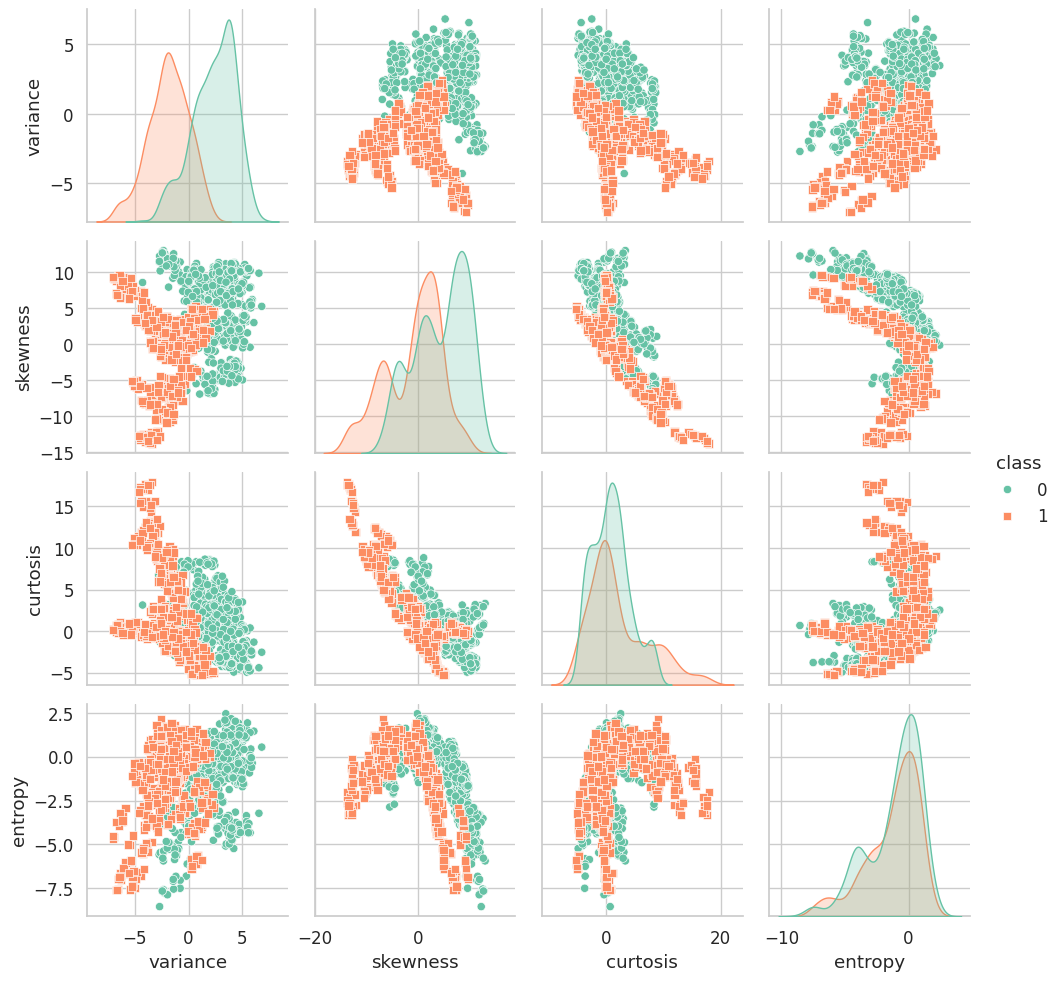

In [7]:

import seaborn as sns
sns.pairplot(billetes, hue="class", markers=["o", "s"], palette="Set2")

Las variables con una mejor separabilidad visual son variance y curtosis ya que se logra ver que los puntos azules y naranjas diferenciados y se nota una ligera frontera entre ellos

In [8]:

X = billetes[['variance', 'curtosis']]
y = billetes['class']

print(X)
print(y)

      variance  curtosis
0      3.62160   -2.8073
1      4.54590   -2.4586
2      3.86600    1.9242
3      3.45660   -4.0112
4      0.32924    4.5718
...        ...       ...
1367   0.40614   -1.4501
1368  -1.38870    6.4774
1369  -3.75030   17.5932
1370  -3.56370   12.3930
1371  -2.54190    2.6842

[1348 rows x 2 columns]
0       0
1       0
2       0
3       0
4       0
       ..
1367    1
1368    1
1369    1
1370    1
1371    1
Name: class, Length: 1348, dtype: int64


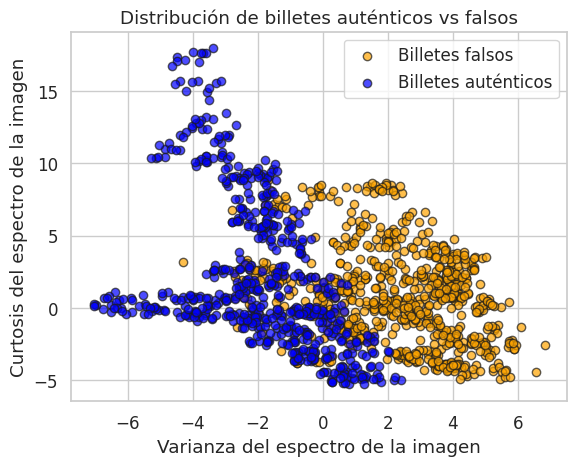

In [9]:
import matplotlib.pyplot as plt

def plot_class_distribution_billetes(X, y):
    """
    Visualiza la distribución de los billetes auténticos vs falsos
    usando las dos variables principales: varianza y curtosis.
    """

    # Convertimos X a numpy array si es un DataFrame
    if hasattr(X, 'values'):
        X = X.values

    # Filtramos las clases
    X_class0 = X[y == 0]   # billetes falsos
    X_class1 = X[y == 1]   # billetes auténticos

    # Graficamos las clases
    plt.scatter(X_class0[:, 0], X_class0[:, 1], label='Billetes falsos', c='orange', alpha=0.7, edgecolors='k')
    plt.scatter(X_class1[:, 0], X_class1[:, 1], label='Billetes auténticos', c='blue', alpha=0.7, edgecolors='k')

    # Etiquetas y título
    plt.xlabel('Varianza del espectro de la imagen')
    plt.ylabel('Curtosis del espectro de la imagen')
    plt.title('Distribución de billetes auténticos vs falsos')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_class_distribution_billetes(X, y)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

In [11]:
print('Conteno de etiquetas en y:', np.bincount(y))
print('Conteno de etiquetas en y_train:', np.bincount(y_train))
print('Conteno de etiquetas en y_test:', np.bincount(y_test))

Conteno de etiquetas en y: [738 610]
Conteno de etiquetas en y_train: [516 427]
Conteno de etiquetas en y_test: [222 183]


In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [13]:
promedio_X1 = X_train_std[:,0].mean()
desv_estand_X1 = X_train_std[:,0].std()
promedio_X2 = X_train_std[:,1].mean()
desv_estand_X2 = X_train_std[:,1].std()

print("Promedio de la característica 1 X1: " + str(promedio_X1))
print("Promedio de la característica 1 X1: " + str(desv_estand_X1))
print("Promedio de la característica 2 X2: " + str(promedio_X2))
print("Promedio de la característica 2 X2: " + str(desv_estand_X2))

Promedio de la característica 1 X1: -1.5069835328952285e-17
Promedio de la característica 1 X1: 0.9999999999999999
Promedio de la característica 2 X2: -3.767458832238071e-17
Promedio de la característica 2 X2: 0.9999999999999999


In [14]:

from sklearn.svm import SVC

svm = SVC(kernel='linear', C=0.1, random_state=1)
svm.fit(X_train_std, y_train)

SVC(C=0.1, kernel='linear', random_state=1)

#**Predicción**

In [15]:
# Obtener las probabilidades de predicción para las primeras 3 muestras del conjunto de prueba

y_train_pred = svm.predict(X_train_std)
y_test_pred = svm.predict(X_test_std)


from sklearn.metrics import confusion_matrix
import seaborn as sns



# **Matrices de confusion**

In [16]:
# Matrices de confusión
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
print('Matriz de confusión - TRAIN (SVM lineal):')
print(cm_train)
print('\nMatriz de confusión - TEST (SVM lineal):')
print(cm_test)


Matriz de confusión - TRAIN (SVM lineal):
[[431  85]
 [ 19 408]]

Matriz de confusión - TEST (SVM lineal):
[[194  28]
 [ 16 167]]


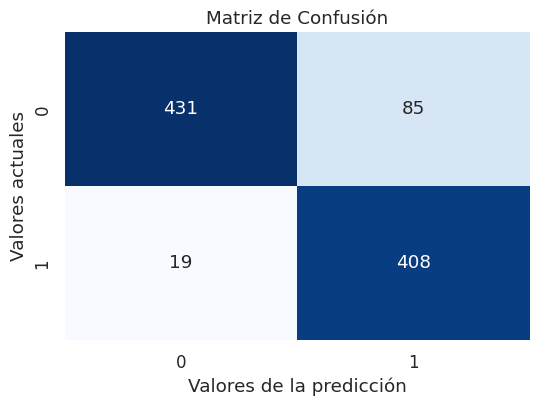

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Graficar la matriz de confusión train
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Valores de la predicción')
plt.ylabel('Valores actuales')
plt.title('Matriz de Confusión')
plt.show()

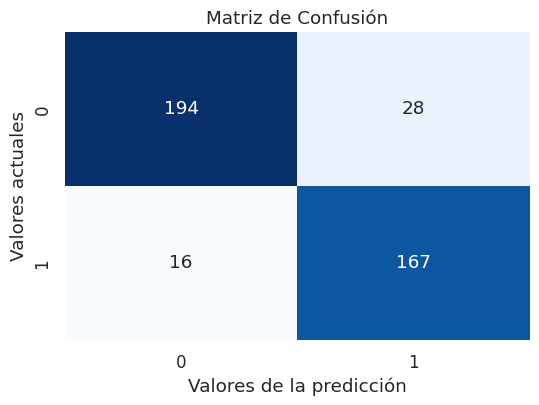

In [18]:
# Graficar la matriz de confusión test
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Valores de la predicción')
plt.ylabel('Valores actuales')
plt.title('Matriz de Confusión')
plt.show()

In [19]:
#-- Calcular todas las métricas explicadas en el aula de clase que se pueden obtener a partir de
#-- los resultados obtenidos en el ítem 5.5.

class metricas_matriz_confusion(object):

  #
    def __init__(self, cm):
        self.TP = cm[1][1]
        self.FP = cm[0][1]
        self.FN = cm[1][0]
        self.TN = cm[0][0]

        self.accuracy = (self.TP+self.TN)/(self.TP+self.FP+self.FN+self.TN)
        self.error_rate = (self.FP+self.FN)/(self.TP+self.FP+self.FN+self.TN)
        self.precision = (self.TP)/(self.TP+self.FP)
        self.recall = (self.TP)/(self.TP+self.FN)
        self.especificity = (self.TN)/(self.TN+self.FP)





In [20]:
#Test

#Calcular las metricas de la matriz de confusion
metrics_ppn_1 =metricas_matriz_confusion(cm_test)


print("El valor de exactitud (accuracy) es: " + str(metrics_ppn_1.accuracy))
print("El valor de tasa de error (error_rate) es: " + str(metrics_ppn_1.error_rate))
print("El valor de precisión (precision) es: " + str(metrics_ppn_1.precision))
print("El valor de recall (sensibilidad / sensitivity / true positive rate) es: " + str(metrics_ppn_1.recall))
print("El valor de especificidad (especificity) es: " + str(metrics_ppn_1.especificity))

El valor de exactitud (accuracy) es: 0.891358024691358
El valor de tasa de error (error_rate) es: 0.10864197530864197
El valor de precisión (precision) es: 0.8564102564102564
El valor de recall (sensibilidad / sensitivity / true positive rate) es: 0.912568306010929
El valor de especificidad (especificity) es: 0.8738738738738738


In [21]:
#Train
metrics_ppn_2 =metricas_matriz_confusion(cm_train)

print("El valor de exactitud (accuracy) es: " + str(metrics_ppn_2.accuracy))
print("El valor de tasa de error (error_rate) es: " + str(metrics_ppn_2.error_rate))
print("El valor de precisión (precision) es: " + str(metrics_ppn_2.precision))
print("El valor de recall (sensibilidad / sensitivity / true positive rate) es: " + str(metrics_ppn_2.recall))
print("El valor de especificidad (especificity) es: " + str(metrics_ppn_2.especificity))

El valor de exactitud (accuracy) es: 0.8897136797454931
El valor de tasa de error (error_rate) es: 0.1102863202545069
El valor de precisión (precision) es: 0.8275862068965517
El valor de recall (sensibilidad / sensitivity / true positive rate) es: 0.955503512880562
El valor de especificidad (especificity) es: 0.8352713178294574


Creación de la función para dibujar las regiones de seperación:

In [24]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=[cmap(idx)], marker=markers[idx], label=cl)

    if test_idx is not None:
        X_test_plot = X[test_idx, :]
        plt.scatter(X_test_plot[:, 0], X_test_plot[:, 1],
                    facecolors='none', edgecolors='black',
                    linewidths=1, marker='o', s=100, label='Test')

# Construimos el conjunto combinado para graficar train + test
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))


Se puede observar el resultado mediante el dibujo de la regiones de seperación sobre los datos de entrenamiento:

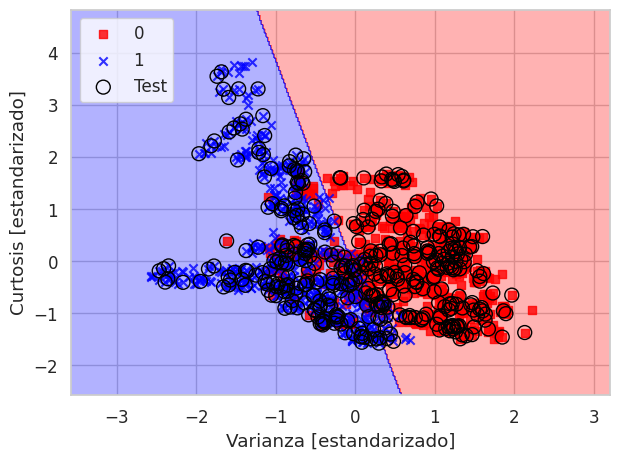

In [25]:
plot_decision_regions(
    X_combined_std,
    y_combined,
    classifier=svm,
    test_idx=range(X_train_std.shape[0], X_combined_std.shape[0])
)

plt.xlabel('Varianza [estandarizado]')
plt.ylabel('Curtosis [estandarizado]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()